**Init**


In [ ]:
!pip install pandas numpy scikit-learn transformers datasets torch underthesea pandarallel

In [ ]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from underthesea import word_tokenize
from pandarallel import pandarallel
from transformers import AutoTokenizer
from datasets import Dataset

# ==========================================
# BƯỚC 1: ĐỌC DỮ LIỆU & GỘP CỘT
# ==========================================
print("=========================================")
print("BƯỚC 1: ĐỌC DỮ LIỆU & GỘP CỘT")
print("=========================================")
df = pd.read_csv('merged_file (1).csv', on_bad_lines='skip', engine='python')
df = df.dropna(subset=['text', 'category']).copy()

print("👉 [MẪU DỮ LIỆU GỐC] - Trích xuất dòng đầu tiên:")
print(f"- Chủ đề (Category): {df['category'].iloc[0]}")
print(f"- Tiêu đề (Title): {df['title'].iloc[0]}")

# Gộp Tiêu đề, Tóm tắt và Nội dung
df['combined_text'] = df['title'].astype(str) + " " + df['description'].astype(str) + " " + df['text'].astype(str)

print("\n👉 [SAU KHI GỘP CỘT] (combined_text):")
print(df['combined_text'].iloc[0][:300] + "...\n")

# ==========================================
# BƯỚC 2: LỌC DỮ LIỆU & MÃ HÓA NHÃN (ĐÃ FIX LỖI)
# ==========================================
print("=========================================")
print("BƯỚC 2: LỌC DỮ LIỆU & MÃ HÓA NHÃN")
print("=========================================")
total_before = len(df)
df = df[df['combined_text'].str.len() >= 30].copy() # Lọc bài ngắn
df = df.drop_duplicates(subset=['combined_text']).copy() # Xóa trùng

# THÊM MỚI: Lọc bỏ các chủ đề (category) có dưới 5 bài viết
category_counts = df['category'].value_counts()
valid_categories = category_counts[category_counts >= 10].index
df = df[df['category'].isin(valid_categories)].copy()

print(f"👉 Số bài báo ban đầu: {total_before}")
print(f"👉 Số bài báo giữ lại (hợp lệ): {len(df)}\n")

label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['category'])
print(f"👉 Danh sách {len(label_encoder.classes_)} chủ đề đã được giữ lại (bỏ các chủ đề quá ít data):")
print(label_encoder.classes_)
print("\n")

# ==========================================
# BƯỚC 3: TÁCH TỪ (WORD SEGMENTATION)
# ==========================================
print("=========================================")
print("BƯỚC 3: TÁCH TỪ BẰNG UNDERTHESEA")
print("=========================================")
pandarallel.initialize(progress_bar=True)

def phobert_preprocess(text):
    return word_tokenize(str(text), format="text")

df["phobert_text"] = df["combined_text"].parallel_apply(phobert_preprocess)

print("\n👉 [SO SÁNH TRƯỚC VÀ SAU KHI TÁCH TỪ] - (Rất quan trọng cho báo cáo):")
print("❌ TRƯỚC (Chưa tách):")
print(df['combined_text'].iloc[0][:300] + "...")
print("\n✅ SAU (Đã nối từ ghép bằng '_', giữ nguyên dấu câu):")
print(df["phobert_text"].iloc[0][:300] + "...\n")

# ==========================================
# BƯỚC 4: CHIA TẬP DATA & TÍNH TRỌNG SỐ
# ==========================================
print("=========================================")
print("BƯỚC 4: CHIA TẬP TRAIN/VAL/TEST")
print("=========================================")
X_train, X_temp, y_train, y_temp = train_test_split(
    df['phobert_text'], df['label'],
    test_size=0.2, random_state=42, stratify=df['label']
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5, random_state=42, stratify=y_temp
)

# Tính toán Class Weights
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights_tensor = torch.tensor(weights, dtype=torch.float)

print(f"👉 Kích thước tập Train: {len(X_train)} bài")
print(f"👉 Kích thước tập Validation: {len(X_val)} bài")
print(f"👉 Kích thước tập Test: {len(X_test)} bài\n")

# ==========================================
# BƯỚC 5: TOKENIZER (MÃ HÓA SANG SỐ CHO PHOBERT)
# ==========================================
print("=========================================")
print("BƯỚC 5: TOKENIZE BẰNG HUGGINGFACE")
print("=========================================")
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base-v2")

train_dataset = Dataset.from_dict({'text': X_train.tolist(), 'label': y_train.tolist()})
val_dataset = Dataset.from_dict({'text': X_val.tolist(), 'label': y_val.tolist()})
test_dataset = Dataset.from_dict({'text': X_test.tolist(), 'label': y_test.tolist()})

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=256)

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

print("\n👉 [MẪU DỮ LIỆU ĐÃ TOKENIZE] (Đây là những con số mà PhoBERT thực sự đọc):")
sample_tokenized = train_dataset[0]
print(f"- Text gốc: {sample_tokenized['text'][:200]}...")
print(f"- Input IDs (20 token đầu tiên): {sample_tokenized['input_ids'][:20]}\n")

print("🎉 HOÀN TẤT TIỀN XỬ LÝ! BẠN ĐÃ SẴN SÀNG CHẠY HÀM TRAIN.")

BƯỚC 1: ĐỌC DỮ LIỆU & GỘP CỘT
👉 [MẪU DỮ LIỆU GỐC] - Trích xuất dòng đầu tiên:
- Chủ đề (Category): bất động sản
- Tiêu đề (Title): Giá đất Cần Giờ tăng gấp 2-3 lần sau một năm

👉 [SAU KHI GỘP CỘT] (combined_text):
Giá đất Cần Giờ tăng gấp 2-3 lần sau một năm Hiệu ứng từ Khu đô thị lấn biển Cần Giờ khởi công cùng làn sóng găm hàng đang khiến giá đất Cần Giờ tăng 30-60% trong một quý và gấp 2 lần trong gần một năm. Chị Trần Thị Quế, một nhà đầu tư nhỏ lẻ, cho biết đã mua một lô đất 150 m2 nằm trong khu dân cư P...

BƯỚC 2: LỌC DỮ LIỆU & MÃ HÓA NHÃN
👉 Số bài báo ban đầu: 6430
👉 Số bài báo giữ lại (hợp lệ): 6389

👉 Danh sách 14 chủ đề đã được giữ lại (bỏ các chủ đề quá ít data):
['bất động sản' 'du lịch' 'giáo dục' 'giải trí' 'góc nhìn'
 'khoa học công nghệ' 'kinh doanh' 'pháp luật' 'sức khỏe' 'thể thao'
 'thời sự' 'tâm sự' 'xe' 'đời sống']


BƯỚC 3: TÁCH TỪ BẰNG UNDERTHESEA
INFO: Pandarallel will run on 1 workers.
INFO: Pandarallel will use Memory file system to transfer data between the 


👉 [SO SÁNH TRƯỚC VÀ SAU KHI TÁCH TỪ] - (Rất quan trọng cho báo cáo):
❌ TRƯỚC (Chưa tách):
Giá đất Cần Giờ tăng gấp 2-3 lần sau một năm Hiệu ứng từ Khu đô thị lấn biển Cần Giờ khởi công cùng làn sóng găm hàng đang khiến giá đất Cần Giờ tăng 30-60% trong một quý và gấp 2 lần trong gần một năm. Chị Trần Thị Quế, một nhà đầu tư nhỏ lẻ, cho biết đã mua một lô đất 150 m2 nằm trong khu dân cư P...

✅ SAU (Đã nối từ ghép bằng '_', giữ nguyên dấu câu):
Giá đất Cần_Giờ tăng gấp 2-3 lần sau một năm Hiệu_ứng từ Khu đô_thị lấn biển Cần_Giờ khởi_công cùng làn_sóng găm hàng đang khiến giá đất Cần_Giờ tăng 30-60 % trong một quý và gấp 2 lần trong gần một năm . Chị Trần_Thị_Quế , một nhà_đầu_tư nhỏ_lẻ , cho biết đã mua một lô đất 150 m2 nằm trong khu dân_...

BƯỚC 4: CHIA TẬP TRAIN/VAL/TEST
👉 Kích thước tập Train: 5111 bài
👉 Kích thước tập Validation: 639 bài
👉 Kích thước tập Test: 639 bài

BƯỚC 5: TOKENIZE BẰNG HUGGINGFACE


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/678 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/895k [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/3.13M [00:00<?, ?B/s]

Map:   0%|          | 0/5111 [00:00<?, ? examples/s]

Map:   0%|          | 0/639 [00:00<?, ? examples/s]

Map:   0%|          | 0/639 [00:00<?, ? examples/s]


👉 [MẪU DỮ LIỆU ĐÃ TOKENIZE] (Đây là những con số mà PhoBERT thực sự đọc):
- Text gốc: Lý_do túi_khí không bung khi xe bị tông_đuôi Tai_nạn tông_đuôi thường tiềm_ẩn rủi_ro chấn_thương cổ , cơ_chế va_chạm này cũng lý_giải vì sao túi_khí không kích_hoạt . Những vụ va_chạm từ phía sau ( tô...
- Input IDs (20 token đầu tiên): [0, 3997, 55795, 1660, 17, 8430, 26, 105, 45, 39219, 3044, 11265, 39219, 3044, 311, 4520, 1928, 1777, 862, 4]

🎉 HOÀN TẤT TIỀN XỬ LÝ! BẠN ĐÃ SẴN SÀNG CHẠY HÀM TRAIN.


In [ ]:
import torch
from torch import nn
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score

print("1. Đang tải mô hình PhoBERT pre-trained...")
# Lấy số lượng chủ đề (14 classes)
num_classes = len(label_encoder.classes_)

# Tải bộ não PhoBERT và gắn thêm lớp phân loại (Classification Head) 14 ngõ ra
model = AutoModelForSequenceClassification.from_pretrained(
    "vinai/phobert-base-v2",
    num_labels=num_classes
)

print("2. Đang thiết lập Custom Trainer với Class Weights...")
# Custom Trainer để áp dụng class_weights_tensor (Ép mô hình học các nhãn ít data)
class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        # Hàm loss CrossEntropy có tích hợp trọng số
        loss_fct = nn.CrossEntropyLoss(weight=class_weights_tensor.to(model.device))
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

# Hàm chấm điểm mô hình khi thi thử trên tập Val
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_macro': f1_score(labels, preds, average='macro')
    }

print("3. Cấu hình siêu tham số (Hyperparameters)...")
training_args = TrainingArguments(
    output_dir="./phobert_news_model",
    eval_strategy="epoch",          # Hết 1 vòng sẽ thi thử trên tập Validation
    save_strategy="epoch",          # Lưu lại mô hình sau mỗi vòng
    learning_rate=2e-5,             # Tốc độ học cực nhỏ để không làm hỏng kiến thức nền của PhoBERT
    per_device_train_batch_size=16, # Mỗi lần đưa 16 bài báo vào GPU học
    per_device_eval_batch_size=16,
    num_train_epochs=4,             # Cho học 4 vòng (Epochs)
    weight_decay=0.01,
    load_best_model_at_end=True,    # Lấy mô hình có điểm thi thử cao nhất
    metric_for_best_model="f1_macro" # Tiêu chí chọn mô hình giỏi nhất là điểm F1-Macro
)

trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

print("\n🚀 BẮT ĐẦU HUẤN LUYỆN (TRAINING)...")
trainer.train()

1. Đang tải mô hình PhoBERT pre-trained...


pytorch_model.bin:   0%|          | 0.00/540M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base-v2
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


2. Đang thiết lập Custom Trainer với Class Weights...
3. Cấu hình siêu tham số (Hyperparameters)...


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=1280, training_loss=0.7108756244182587, metrics={'train_runtime': 1142.7346, 'train_samples_per_second': 17.89, 'train_steps_per_second': 1.12, 'total_flos': 2689810985398272.0, 'train_loss': 0.7108756244182587, 'epoch': 4.0})

1. Đang dự đoán trên tập Test...



📊 BÁO CÁO KẾT QUẢ PHÂN LOẠI (CLASSIFICATION REPORT)
                    precision    recall  f1-score   support

      bất động sản     0.9562    0.9850    0.9704       133
           du lịch     1.0000    0.3333    0.5000         3
          giáo dục     0.9423    0.9245    0.9333        53
          giải trí     0.4000    0.6667    0.5000         3
          góc nhìn     1.0000    0.9774    0.9886       177
khoa học công nghệ     0.8621    0.8621    0.8621        29
        kinh doanh     0.7778    0.6364    0.7000        11
         pháp luật     0.9630    0.8667    0.9123        30
          sức khỏe     0.9200    1.0000    0.9583        23
          thể thao     0.9500    1.0000    0.9744        19
           thời sự     0.8814    0.9286    0.9043        56
            tâm sự     1.0000    1.0000    1.0000         7
                xe     0.9579    0.9785    0.9681        93
          đời sống     0.0000    0.0000    0.0000         2

          accuracy                         0.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


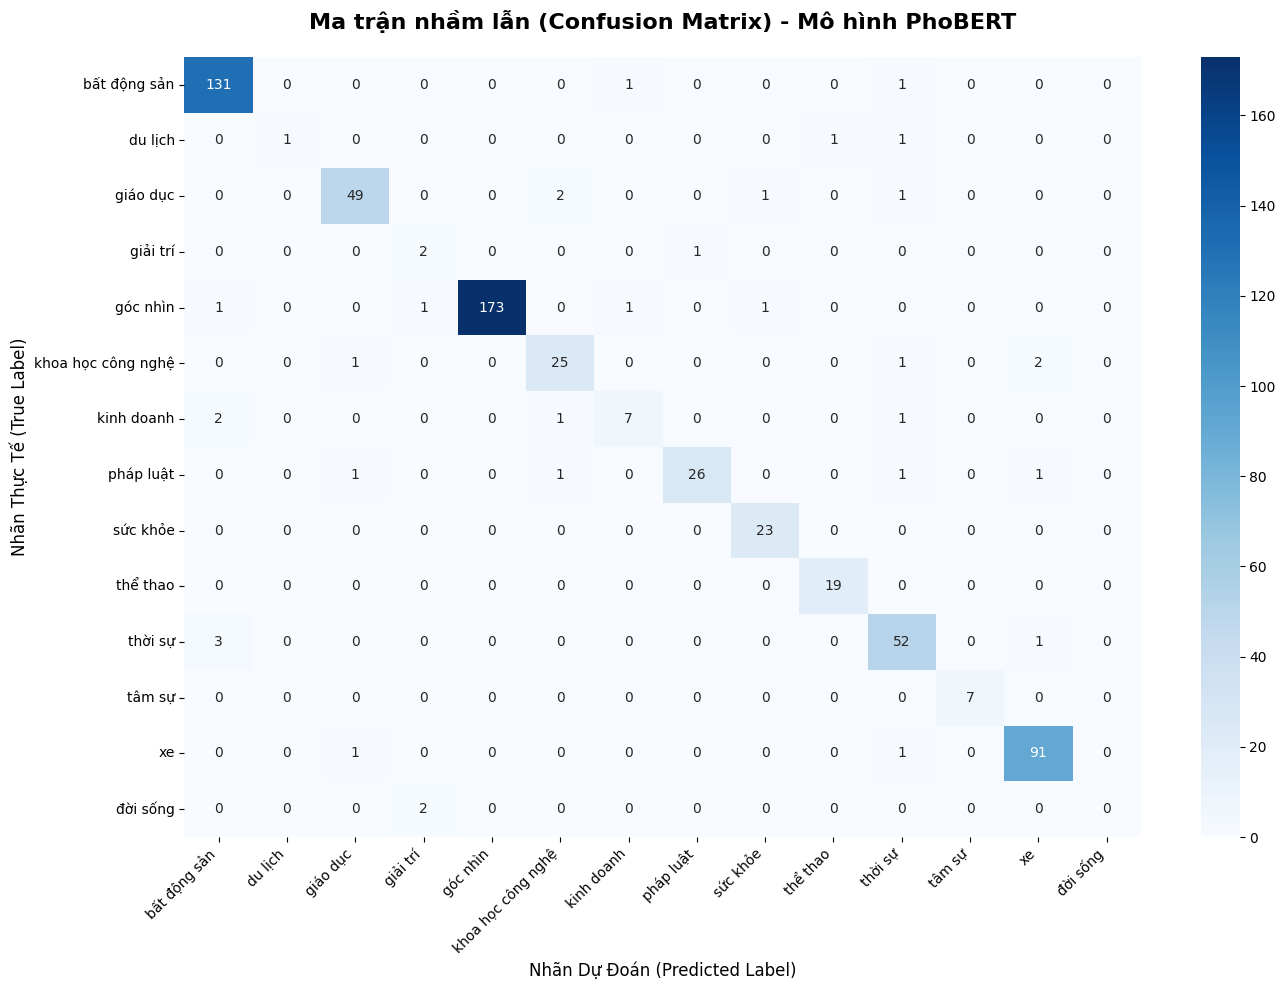


3. Đang vẽ biểu đồ F1-Score...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/tmp/ipykernel_525/1509757691.py:49: FutureWarnin

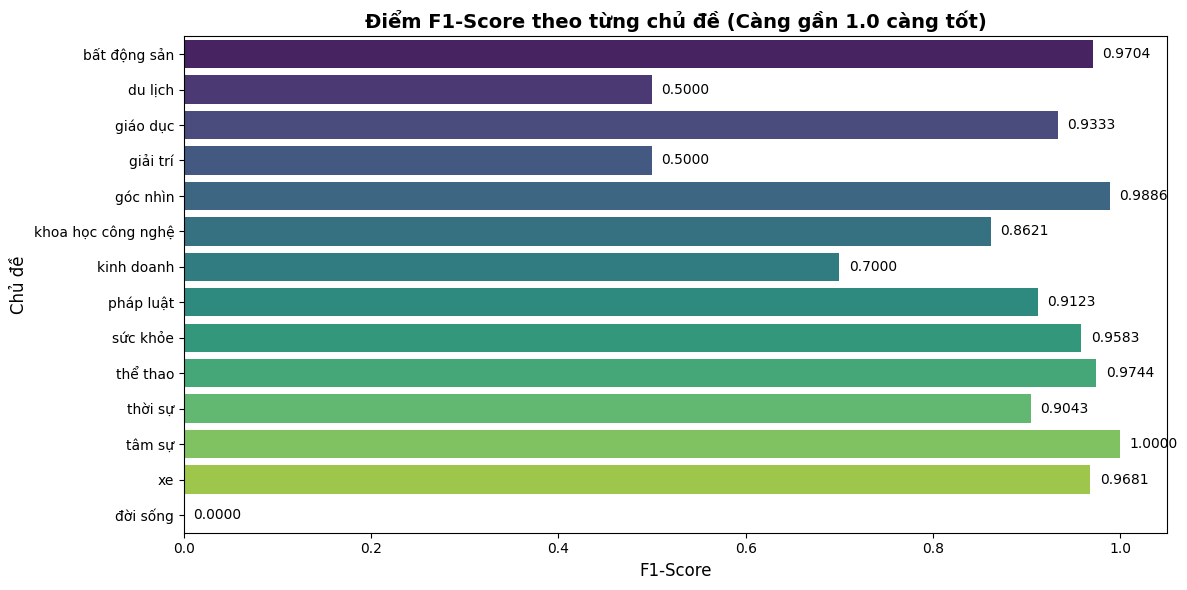

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

print("1. Đang dự đoán trên tập Test...")
# Gọi trainer để dự đoán trên tập Test
predictions = trainer.predict(test_dataset)
# Lấy nhãn có xác suất cao nhất
y_pred = predictions.predictions.argmax(-1)
y_true = y_test.tolist()
target_names = label_encoder.classes_

# ==========================================
# BÁO CÁO DẠNG TEXT (CLASSIFICATION REPORT)
# ==========================================
print("\n=======================================================")
print("📊 BÁO CÁO KẾT QUẢ PHÂN LOẠI (CLASSIFICATION REPORT)")
print("=======================================================")
report = classification_report(y_true, y_pred, target_names=target_names, digits=4)
print(report)

# ==========================================
# TRỰC QUAN HÓA 1: MA TRẬN NHẦM LẪN (CONFUSION MATRIX)
# ==========================================
print("\n2. Đang vẽ biểu đồ Ma trận nhầm lẫn...")
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 10))
# Vẽ heatmap với màu xanh dương (Blues)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Ma trận nhầm lẫn (Confusion Matrix) - Mô hình PhoBERT', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Nhãn Dự Đoán (Predicted Label)', fontsize=12)
plt.ylabel('Nhãn Thực Tế (True Label)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ==========================================
# TRỰC QUAN HÓA 2: BIỂU ĐỒ F1-SCORE TỪNG CHỦ ĐỀ
# ==========================================
print("\n3. Đang vẽ biểu đồ F1-Score...")
report_dict = classification_report(y_true, y_pred, target_names=target_names, output_dict=True)
f1_scores = [report_dict[class_name]['f1-score'] for class_name in target_names]

plt.figure(figsize=(12, 6))
# Vẽ biểu đồ cột
sns.barplot(x=f1_scores, y=target_names, palette='viridis')
plt.title('Điểm F1-Score theo từng chủ đề (Càng gần 1.0 càng tốt)', fontsize=14, fontweight='bold')
plt.xlabel('F1-Score', fontsize=12)
plt.ylabel('Chủ đề', fontsize=12)
plt.xlim(0, 1.05)

# Thêm số liệu lên từng cột
for i, v in enumerate(f1_scores):
    plt.text(v + 0.01, i, f"{v:.4f}", va='center', fontsize=10)

plt.tight_layout()
plt.show()

In [15]:
# Lệnh này sẽ lưu toàn bộ "chất xám" từ RAM xuống ổ cứng Colab
trainer.save_model("./phobert_best_model")
tokenizer.save_pretrained("./phobert_best_model")
print("✅ Đã tạo thư mục và lưu mô hình thành công!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Đã tạo thư mục và lưu mô hình thành công!


In [17]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from underthesea import word_tokenize

# ==========================================
# 1. KHỞI TẠO HỆ THỐNG
# ==========================================
print("⏳ Đang khởi động hệ thống suy luận PhoBERT...")
model_path = "./phobert_best_model"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

# Đưa mô hình lên GPU nếu có
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

# Khai báo trực tiếp 14 chủ đề để không bị lỗi biến bốc hơi
classes = [
    'bất động sản', 'du lịch', 'giáo dục', 'giải trí', 'góc nhìn',
    'khoa học công nghệ', 'kinh doanh', 'pháp luật', 'sức khỏe', 'thể thao',
    'thời sự', 'tâm sự', 'xe', 'đời sống'
]

# ==========================================
# 2. HÀM DỰ ĐOÁN (FORMAT CHUẨN ĐỂ CHỤP BÁO CÁO)
# ==========================================
def predict_news(text):
    # Tiền xử lý văn bản
    processed_text = word_tokenize(str(text), format="text")
    inputs = tokenizer(
        processed_text,
        padding="max_length",
        truncation=True,
        max_length=256,
        return_tensors="pt"
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Dự đoán
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1).cpu().numpy()[0]

    top3_idx = np.argsort(probs)[-3:][::-1]

    # In ra giao diện Console đẹp mắt
    print("\n" + "═" * 70)
    print(" BẢN TIN ĐẦU VÀO:")
    print(f"   {text[:200]}...")
    print("─" * 70)
    print(f" KẾT QUẢ DỰ ĐOÁN CHÍNH: [{classes[top3_idx[0]].upper()}]")
    print(f"   Độ tự tin (Confidence): {probs[top3_idx[0]]*100:.2f}%")
    print("─" * 70)
    print(" CÁC NHÃN TIỀM NĂNG KHÁC:")
    for i in range(1, 3):
        idx = top3_idx[i]
        print(f"   • {classes[idx].capitalize()}: {probs[idx]*100:.2f}%")
    print("═" * 70)

print("✅ Hệ thống đã sẵn sàng! Bắt đầu chạy thử nghiệm...\n")

# ==========================================
# 3. KỊCH BẢN KIỂM THỬ (TEST DEMO)
# ==========================================
# Mẫu 1: Dễ phân loại
text_demo_1 = """Thị trường chung cư đầu năm 2024 chứng kiến đà tăng giá chóng mặt.
Nhiều dự án ở vùng ven cũng đã chạm mốc 50-60 triệu đồng/m2, thiết lập một mặt bằng giá mới
khó tiếp cận cho người lao động."""

# Mẫu 2: Đánh lừa (Chủ đề Xe nhưng dùng nhiều từ vựng Kinh doanh)
text_demo_2 = """Hãng xe điện VinFast chính thức công bố doanh thu quý 3 đạt mức kỷ lục,
lợi nhuận tăng vọt nhờ vào việc xuất khẩu sang thị trường Mỹ. Cổ phiếu của hãng cũng
tăng trần trong phiên giao dịch sáng nay."""

predict_news(text_demo_1)
predict_news(text_demo_2)

⏳ Đang khởi động hệ thống suy luận PhoBERT...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Hệ thống đã sẵn sàng! Bắt đầu chạy thử nghiệm...


══════════════════════════════════════════════════════════════════════
 BẢN TIN ĐẦU VÀO:
   Thị trường chung cư đầu năm 2024 chứng kiến đà tăng giá chóng mặt. 
Nhiều dự án ở vùng ven cũng đã chạm mốc 50-60 triệu đồng/m2, thiết lập một mặt bằng giá mới 
khó tiếp cận cho người lao động....
──────────────────────────────────────────────────────────────────────
 KẾT QUẢ DỰ ĐOÁN CHÍNH: [BẤT ĐỘNG SẢN]
   Độ tự tin (Confidence): 91.07%
──────────────────────────────────────────────────────────────────────
 CÁC NHÃN TIỀM NĂNG KHÁC:
   • Kinh doanh: 3.05%
   • Thời sự: 0.90%
══════════════════════════════════════════════════════════════════════

══════════════════════════════════════════════════════════════════════
 BẢN TIN ĐẦU VÀO:
   Hãng xe điện VinFast chính thức công bố doanh thu quý 3 đạt mức kỷ lục, 
lợi nhuận tăng vọt nhờ vào việc xuất khẩu sang thị trường Mỹ. Cổ phiếu của hãng cũng 
tăng trần trong phiên giao dịch sáng nay....
──────